# Escenario D: Notebook de analisis asistido por IA

Este notebook fue generado como punto de partida para analisis exploratorio en el experimento de comparacion.
Incluye celdas para medir convergencia de Monte Carlo y visualizar resultados.

## Objetivo

Evaluar como cambia el error de estimacion de $\pi$ cuando aumenta el numero de muestras en Monte Carlo.

In [1]:
import math
import random
from statistics import mean

import matplotlib.pyplot as plt

In [2]:
def estimar_pi_monte_carlo(n_muestras: int) -> float:
    """Estima pi usando puntos aleatorios en el cuadrado unitario."""
    if n_muestras <= 0:
        raise ValueError('n_muestras debe ser mayor a 0')

    dentro_del_circulo = 0
    for _ in range(n_muestras):
        x = random.random()
        y = random.random()
        if x * x + y * y <= 1.0:
            dentro_del_circulo += 1

    return 4.0 * dentro_del_circulo / n_muestras

In [3]:
muestras = [100, 300, 1_000, 3_000, 10_000, 30_000]
replicas = 10

resumen = []
for n in muestras:
    estimaciones = [estimar_pi_monte_carlo(n) for _ in range(replicas)]
    promedio = mean(estimaciones)
    error_abs = abs(promedio - math.pi)
    resumen.append((n, promedio, error_abs))

for n, promedio, error_abs in resumen:
    print(f'n={n:>6} | pi_promedio={promedio:.6f} | error_abs={error_abs:.6f}')

n=   100 | pi_promedio=3.104000 | error_abs=0.037593
n=   300 | pi_promedio=3.101333 | error_abs=0.040259
n=  1000 | pi_promedio=3.180800 | error_abs=0.039207
n=  3000 | pi_promedio=3.140800 | error_abs=0.000793
n= 10000 | pi_promedio=3.143400 | error_abs=0.001807
n= 30000 | pi_promedio=3.139680 | error_abs=0.001913


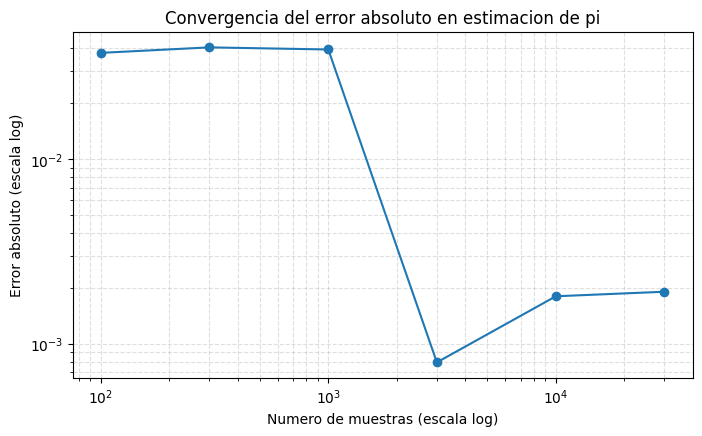

In [4]:
x = [item[0] for item in resumen]
y = [item[2] for item in resumen]

plt.figure(figsize=(8, 4.5))
plt.plot(x, y, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.title('Convergencia del error absoluto en estimacion de pi')
plt.xlabel('Numero de muestras (escala log)')
plt.ylabel('Error absoluto (escala log)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

## Siguientes pasos sugeridos

1. Comparar contra tu implementacion de QMC del proyecto.
2. Guardar tablas intermedias en CSV para trazabilidad.
3. Repetir con varias semillas y analizar varianza.